In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# self done most important
df = pd.read_csv(r"C:\Users\srcsi\OneDrive\Desktop\100daysml\day27\cars.csv")
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
df.isnull().sum()
df.drop_duplicates()
df.shape

     brand  km_driven    fuel         owner  selling_price
0   Maruti     145500  Diesel   First Owner         450000
1    Skoda     120000  Diesel  Second Owner         370000
2    Honda     140000  Petrol   Third Owner         158000
3  Hyundai     127000  Diesel   First Owner         225000
4   Maruti     120000  Petrol   First Owner         130000
(8128, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   brand          8128 non-null   object
 1   km_driven      8128 non-null   int64 
 2   fuel           8128 non-null   object
 3   owner          8128 non-null   object
 4   selling_price  8128 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 317.6+ KB
None
          km_driven  selling_price
count  8.128000e+03   8.128000e+03
mean   6.981951e+04   6.382718e+05
std    5.655055e+04   8.062534e+05
min    1.000000e+00   2.999900e+

(8128, 5)

In [99]:
for col in df.columns:
    #print(df[col].value_counts())
    print(col,df[col].nunique())

brand 32
km_driven 921
fuel 4
owner 5
selling_price 677


#brand -nominal data 32categories
km_driven -int
fuel-4 cat nominal
selling price= output
owner 5 odinary data
#   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   brand          8128 non-null   object
 1   km_driven      8128 non-null   int64 
 2   fuel           8128 non-null   object
 3   owner          8128 non-null   object
 4   km_driven  8128 non-null   int64 


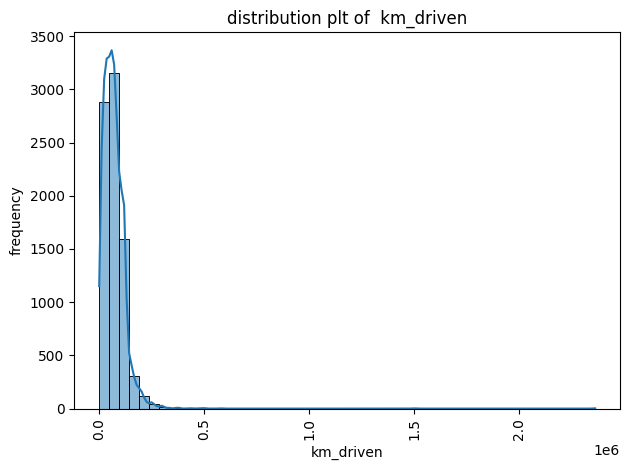

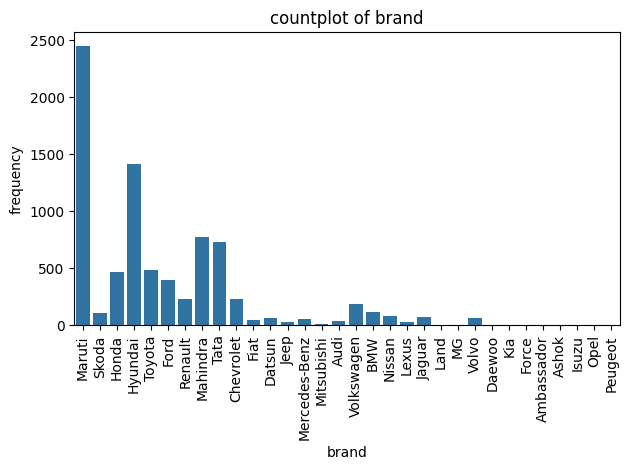

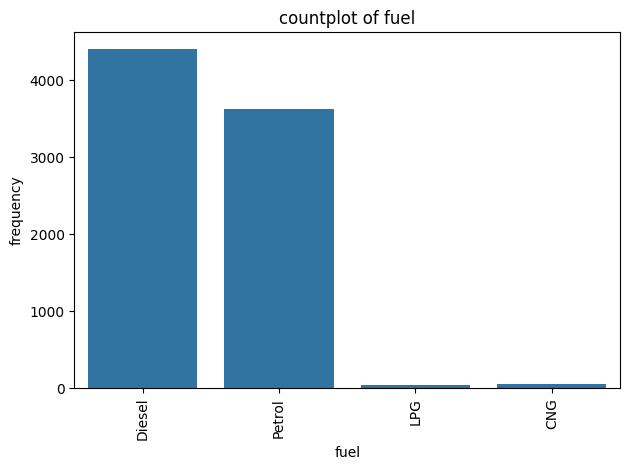

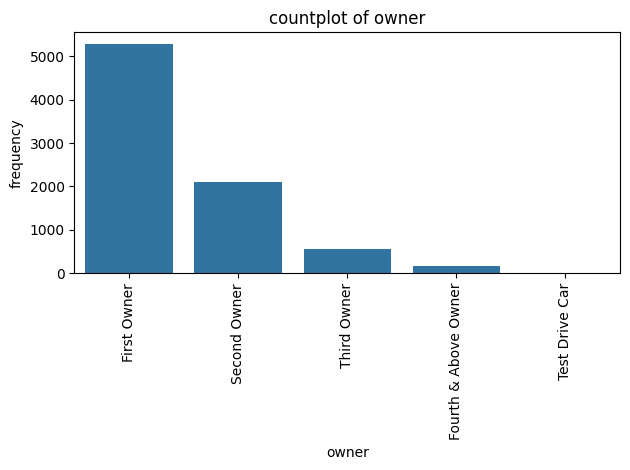

<Axes: ylabel='km_driven'>

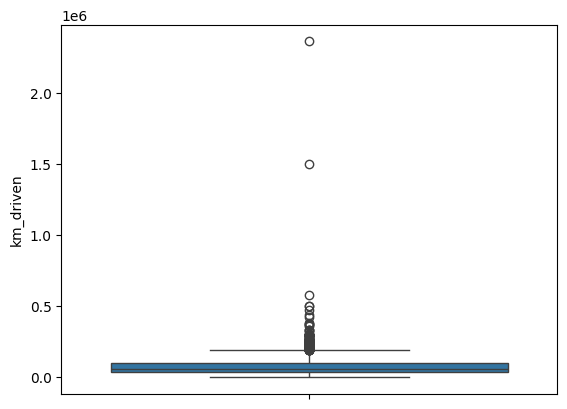

In [100]:
#graph
numeric=["km_driven"]
cat=["brand",'fuel','owner']
for i in numeric:
    plt.Figure(figsize=(6,4))
    sns.histplot(x=df[i],kde=True,bins=50)
    plt.title(f"distribution plt of  {i}")
    plt.xlabel(i)
    plt.xticks(rotation=90)
    plt.ylabel("frequency")
    plt.tight_layout()
    
    plt.show()

for i in cat:
    plt.Figure(figsize=(6,4))
    sns.countplot(x=df[i])
    plt.title(f"countplot of {i}")
    plt.xticks(rotation=90)
    plt.xlabel(i)
    plt.ylabel("frequency")
    plt. tight_layout()
    plt.show()
    #boxplot
sns.boxplot(df["km_driven"])

In [101]:
q1=df["km_driven"].quantile(.25)
q3=df["km_driven"].quantile(.75)
iqr=q3-q1
up=q3+(1.5)*iqr
lb=q1-(1.5)*iqr
outlier=df[(df["km_driven"]>up )| (df["km_driven"]<lb)]
outlier

,brand,km_driven,fuel,owner,selling_price
272,Maruti,193000,Diesel,First Owner,320000
287,Mahindra,207890,Diesel,Second Owner,210000
394,Toyota,240000,Diesel,Third Owner,250000
396,Hyundai,214000,Petrol,Second Owner,340000
397,Hyundai,214000,Diesel,Second Owner,340000
...,...,...,...,...,...
8031,Chevrolet,195000,Diesel,First Owner,275000
8033,Hyundai,200000,Diesel,Second Owner,450000
8071,Toyota,200000,Diesel,Second Owner,425000
8077,Toyota,250000,Diesel,First Owner,550000


In [102]:
#drop from main dataframe
#df.dr-op(outlier.index,axis=0)
#df.reset_index(drop=True, inplace=True)
#lets do chnage 1
df["km_driven"]=np.where(df["km_driven"]>up,up,np.where(df["km_driven"]<lb,lb,df["km_driven"]))

<Axes: ylabel='km_driven'>

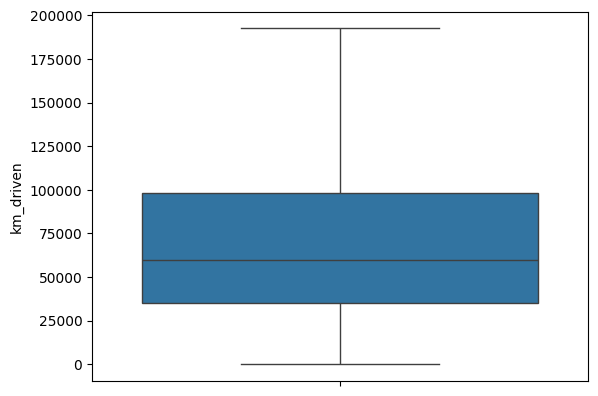

In [103]:
sns.boxplot(df["km_driven"])

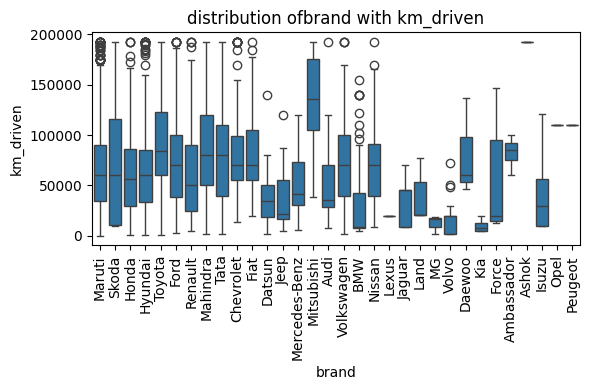

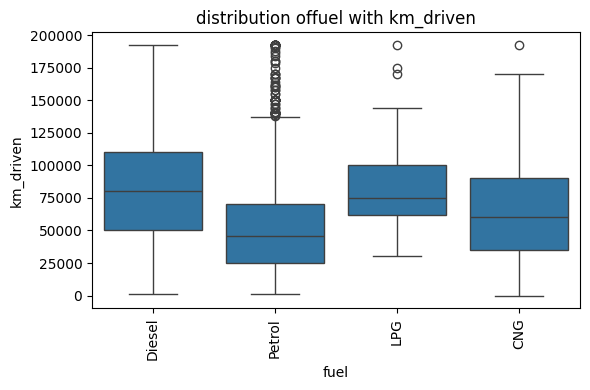

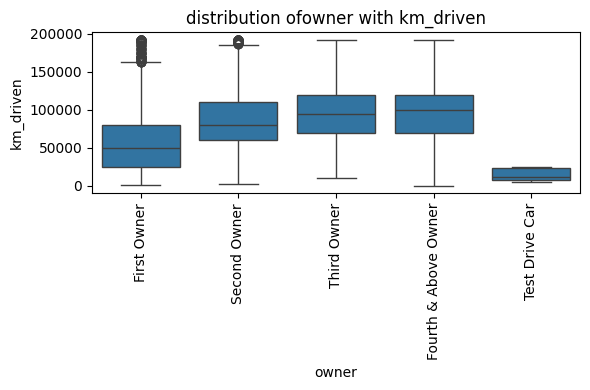

In [104]:
for i in cat:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[i],y=df["km_driven"])
    plt.title(f"distribution of{i} with km_driven")
    plt.xlabel(i)
    plt.xticks(rotation=90)
    plt.ylabel("km_driven")
    plt.tight_layout()
    plt.show()

In [105]:
df["km_driven"].skew()


np.float64(0.7419815672914372)

<Axes: >

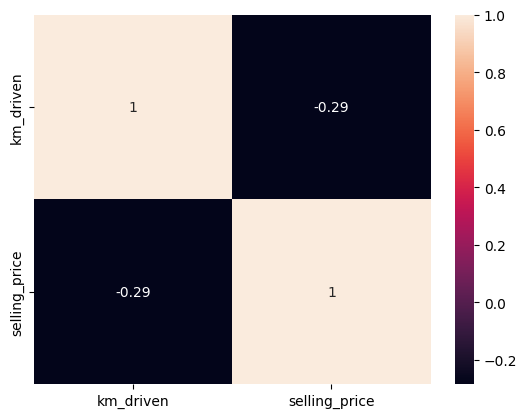

In [106]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

#brand,fuel one hot encoding
#km_driven robust
#owner -ordinary

In [107]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["selling_price"])
y = df["selling_price"]




X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)


first threshold was 100 the coor is max of other
then 50 then also max that why convert to 20

In [108]:
"""threshold=20
count=X_train["brand"].value_counts()
remaing=count[(count>=10)].index
X_train["brand"]=X_train["brand"].apply(lambda x:x if x in remaing else "other" )
X_test["brand"]=X_test["brand"].apply(lambda x:x if x in remaing else "other")
"""

"""# ---- brand-wise km z-score (train-based)
brand_mean = X_train.groupby("brand")["km_driven"].mean()
brand_std  = X_train.groupby("brand")["km_driven"].std().replace(0, 1)

X_train["km_z_by_brand"] = (X_train["km_driven"] - X_train["brand"].map(brand_mean)) / X_train["brand"].map(brand_std)
X_test["km_z_by_brand"]  = (X_test["km_driven"]  - X_test["brand"].map(brand_mean))  / X_test["brand"].map(brand_std)

# handle unseen brands in test
X_train["km_z_by_brand"] = X_test["km_z_by_brand"].fillna(0)

X_test["km_z_by_brand"] = X_test["km_z_by_brand"].fillna(0) """


'# ---- brand-wise km z-score (train-based)\nbrand_mean = X_train.groupby("brand")["km_driven"].mean()\nbrand_std  = X_train.groupby("brand")["km_driven"].std().replace(0, 1)\n\nX_train["km_z_by_brand"] = (X_train["km_driven"] - X_train["brand"].map(brand_mean)) / X_train["brand"].map(brand_std)\nX_test["km_z_by_brand"]  = (X_test["km_driven"]  - X_test["brand"].map(brand_mean))  / X_test["brand"].map(brand_std)\n\n# handle unseen brands in test\nX_train["km_z_by_brand"] = X_test["km_z_by_brand"].fillna(0)\n\nX_test["km_z_by_brand"] = X_test["km_z_by_brand"].fillna(0) '

In [109]:
from sklearn.preprocessing import OneHotEncoder, RobustScaler,OrdinalEncoder

**** in onehotencoder always do sparse_output=False
or use .toarray

In [110]:
from sklearn.compose import ColumnTransformer
transform=ColumnTransformer(transformers=[
    ("ohe",OneHotEncoder(sparse_output=False,drop="first", handle_unknown="ignore"),["fuel","brand"]),
    ('re',RobustScaler(),["km_driven"]),
    ('oe',OrdinalEncoder(categories=[[
    'Test Drive Car',
    'First Owner',
    'Second Owner',
    'Third Owner',
    
    'Fourth & Above Owner'
]]),["owner"])],remainder='passthrough')
X_train_encoded=transform.fit_transform(X_train)
X_test_encoded=transform.transform(X_test)
# to get shape
print(transform.fit_transform(X_train).shape)
print(transform.transform(X_test).shape)
print(X_train_encoded.dtype)
print(X_test_encoded.dtype)


(5445, 34)
(2683, 34)
float64
float64


c:\Users\srcsi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\srcsi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [111]:
# Convert to dense array if needed
"""if hasattr(X_train_encoded, "toarray"):
    X_train_encoded = X_train_encoded.toarray()
    X_test_encoded  = X_test_encoded.toarray()
    """
"""This exists because ColumnTransformer + OneHotEncoder often returns a SPARSE MATRIX, not a normal NumPy array."""
#this uper code is written if in onehotencoding sparse_output=true(by_default)
#so does convert into array directly
feature_names=transform.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_encoded,columns=feature_names,
index=X_train.index)
X_test_df=pd.DataFrame(X_test_encoded,columns=feature_names,index=X_test.index)
print(X_train_df.shape,X_test_df.shape)
print(X_train_df.head())

(5445, 34) (2683, 34)
      ohe__fuel_Diesel  ohe__fuel_LPG  ohe__fuel_Petrol  ohe__brand_Audi  \
4446               1.0            0.0               0.0              0.0   
2154               1.0            0.0               0.0              0.0   
1344               1.0            0.0               0.0              0.0   
7856               0.0            0.0               1.0              0.0   
6107               1.0            0.0               0.0              0.0   

      ohe__brand_BMW  ohe__brand_Chevrolet  ohe__brand_Daewoo  \
4446             0.0                   0.0                0.0   
2154             0.0                   0.0                0.0   
1344             0.0                   0.0                0.0   
7856             0.0                   0.0                0.0   
6107             0.0                   0.0                0.0   

      ohe__brand_Datsun  ohe__brand_Fiat  ohe__brand_Force  ...  \
4446                0.0              0.0               0.0  ...

i didnot use this feature selection

In [112]:
#no used 
#choosing features

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train_df, y_train)

importance = pd.Series(
    rf.feature_importances_,
    index=X_train_df.columns
).sort_values(ascending=False)

print(importance)


ohe__brand_BMW              0.300712
re__km_driven               0.190701
ohe__brand_Lexus            0.115336
ohe__brand_Volvo            0.106463
ohe__brand_Jaguar           0.082401
ohe__brand_Mercedes-Benz    0.052910
oe__owner                   0.028916
ohe__brand_Audi             0.026749
ohe__brand_Toyota           0.022070
ohe__brand_Jeep             0.017146
ohe__fuel_Diesel            0.017084
ohe__brand_Land             0.009406
ohe__fuel_Petrol            0.004883
ohe__brand_Tata             0.004660
ohe__brand_Skoda            0.003901
ohe__brand_Honda            0.003257
ohe__brand_Ford             0.002148
ohe__brand_Hyundai          0.001849
ohe__brand_Mahindra         0.001770
ohe__brand_MG               0.001462
ohe__brand_Volkswagen       0.001237
ohe__brand_Maruti           0.001084
ohe__brand_Chevrolet        0.001081
ohe__brand_Mitsubishi       0.000603
ohe__brand_Renault          0.000530
ohe__brand_Kia              0.000501
ohe__brand_Nissan           0.000431
o

In [113]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    rf, X_test_df, y_test,
    n_repeats=10, random_state=42
)

perm = pd.Series(
    r.importances_mean,
    index=X_train_df.columns
).sort_values(ascending=False)

print(perm.shape)
perms=perm.index.to_numpy()
"""perm → pandas Series

perm.index → feature names (column names)

perm.values → importance scores"""
#It converts the pandas Index into a NumPy array:
# Select top 15 features
#i use all 26 featuresthen accuracy is good
topfeatures = perm.to_numpy()

print(topfeatures)
#print(len(topfeatures))
X_train_f=X_train_df[perms]
X_test_f=X_test_df[perms]
print(perms)



(34,)
[ 3.71685870e-01  3.71223755e-01  2.52670149e-01  1.37919473e-01
  1.31189028e-01  9.14173060e-02  7.37993605e-02  5.54064803e-02
  3.94291107e-02  3.48372989e-02  3.06070623e-02  1.70656157e-02
  4.49952033e-03  2.94552142e-03  2.23979546e-03  1.96899494e-03
  1.83636644e-03  8.56377873e-04  7.50205779e-04  5.72422398e-04
  4.64424187e-04  3.90642232e-04  2.88587858e-04  2.28323497e-04
  1.43380442e-04  3.15601478e-05  1.72987061e-05  1.18482203e-05
  1.07999640e-05  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -1.16130163e-04]
['ohe__brand_Lexus' 'ohe__brand_BMW' 're__km_driven' 'ohe__brand_Volvo'
 'ohe__brand_Jaguar' 'ohe__brand_Audi' 'ohe__fuel_Diesel'
 'ohe__brand_Toyota' 'oe__owner' 'ohe__brand_Mercedes-Benz'
 'ohe__brand_Jeep' 'ohe__brand_Land' 'ohe__brand_Honda' 'ohe__brand_Skoda'
 'ohe__brand_Mahindra' 'ohe__fuel_Petrol' 'ohe__brand_Tata'
 'ohe__brand_Chevrolet' 'ohe__brand_Mitsubishi' 'ohe__brand_Renault'
 'ohe__brand_Ford' 'ohe__brand_Volkswagen' 'oh

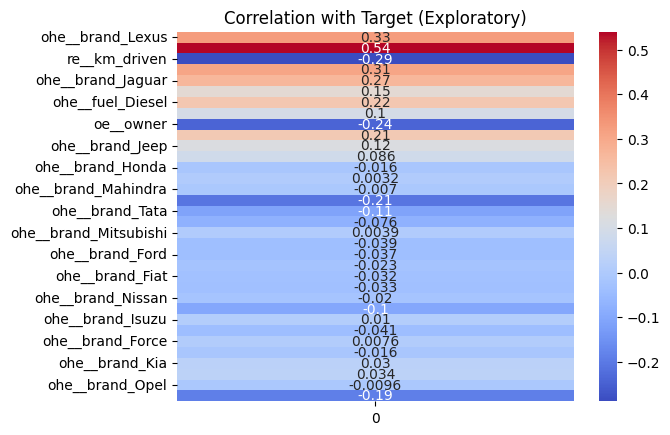

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X_train_f.corrwith(y_train)

sns.heatmap(
    corr.to_frame(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation with Target (Exploratory)")
plt.show()


In [115]:
X_train_df.isnull().sum()


ohe__fuel_Diesel            0
ohe__fuel_LPG               0
ohe__fuel_Petrol            0
ohe__brand_Audi             0
ohe__brand_BMW              0
ohe__brand_Chevrolet        0
ohe__brand_Daewoo           0
ohe__brand_Datsun           0
ohe__brand_Fiat             0
ohe__brand_Force            0
ohe__brand_Ford             0
ohe__brand_Honda            0
ohe__brand_Hyundai          0
ohe__brand_Isuzu            0
ohe__brand_Jaguar           0
ohe__brand_Jeep             0
ohe__brand_Kia              0
ohe__brand_Land             0
ohe__brand_Lexus            0
ohe__brand_MG               0
ohe__brand_Mahindra         0
ohe__brand_Maruti           0
ohe__brand_Mercedes-Benz    0
ohe__brand_Mitsubishi       0
ohe__brand_Nissan           0
ohe__brand_Opel             0
ohe__brand_Renault          0
ohe__brand_Skoda            0
ohe__brand_Tata             0
ohe__brand_Toyota           0
ohe__brand_Volkswagen       0
ohe__brand_Volvo            0
re__km_driven               0
oe__owner 

In [116]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train_df,y_train)
y_lrpre=lr.predict(X_test_df)
from sklearn.metrics import r2_score
r2le=r2_score(y_test,y_lrpre)
print("r2score",r2le)
n=X_test_f.shape[0]
p=X_test_f.shape[1]
adj_r2=1-((1-r2le)*(n-1))/(n-p-1)
adj_r2

r2score 0.7673461865725208


0.7643589397233765

In [117]:
#cross validation
from sklearn.model_selection import cross_val_score
cv_sc=cross_val_score(lr,X_train_f,y_train,cv=5)
print(cv_sc.mean(),cv_sc.std())

0.7542531377090519 0.04909213968274673


In [118]:
from sklearn.neighbors import KNeighborsRegressor
kn=KNeighborsRegressor(n_neighbors=7)
kn.fit(X_train_f,y_train)
y_knpre=kn.predict(X_test_f)
r2kn=r2_score(y_test,y_knpre)
print(r2kn)
n=X_test_f.shape[0]
p=X_test_f.shape[1]
adj_r2k=1-((1-r2kn)*(n-1))/(n-p-1)
print(adj_r2k)
cv_kn=cross_val_score(kn,X_train_f,y_train,cv=5)
print(cv_kn.mean(),cv_kn.std())

0.7979761380152537
0.7953821760411293
0.8339747122534285 0.03908772233956658


In [119]:
from sklearn.svm import SVR,SVC
svre=SVR()#regresion
svcl=SVC()#classification
svcl.fit(X_train_f,y_train)
svre.fit(X_train_f,y_train)
y_pre_svr=svre.predict(X_test_f)
y_pre_svc=svcl.predict(X_test_f)
r2svr=r2_score(y_test,y_pre_svr)
print("r2 of svr:",r2svr)
r2svc=r2_score(y_test,y_pre_svc)
print("r2 for svc",r2svc)
n=X_test_f.shape[0]
p=X_test_f.shape[1]
adjr2svc=1-((1-r2svc)*(n-1))/(n-p-1)
print("adj r2 of svc",adjr2svc)
adjr2svr=1-((1-r2svr)*(n-1))/(n-p-1)
print("adjr2 of svr",adjr2svr)


r2 of svr: -0.05647108652601074
r2 for svc 0.6455193347886561
adj r2 of svc 0.6409678458848851
adjr2 of svr -0.07003604760678295


In [120]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(X_train_f,y_train)
y_prenb=nb.predict(X_test_f)


In [121]:
from sklearn.metrics import accuracy_score,f1_score,classification_report
print("Accuracy:", accuracy_score(y_test, y_prenb))
print("Report:", classification_report(y_test, y_prenb))

Accuracy: 0.049198658218412225
Report:               precision    recall  f1-score   support

       29999       0.00      0.00      0.00         0
       30000       0.00      0.00      0.00         0
       31000       0.00      0.00      0.00         1
       31504       0.00      0.00      0.00         1
       33351       0.00      0.00      0.00         0
       33983       0.00      0.00      0.00         0
       35000       0.00      0.00      0.00         1
       39000       0.00      0.00      0.00         1
       40000       0.00      0.00      0.00         3
       42000       0.00      0.00      0.00         1
       45000       0.00      0.00      0.00         3
       45957       0.11      1.00      0.20         1
       50000       0.00      0.00      0.00         6
       52000       0.00      0.00      0.00         1
       55000       0.00      0.00      0.00         4
       56000       0.00      0.00      0.00         1
       57000       0.00      0.00      0.0

c:\Users\srcsi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\srcsi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\srcsi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [122]:
import joblib
joblib.dump(lr,"liner_model.pkl")
joblib.dump(kn,'knn_model.pkl')
joblib.dump(perms,"features.pkl")
joblib.dump(transform,'transformer.pkl')


['transformer.pkl']